# PROYECTO FINAL INTEGRADOR - MERCADO DE VEHÍCULOS USADOS

## Integrantes

- Carvallo Neciosup Kevin Esty
- Delerna Infantes Anderson Josue
- Mogollon Flores Josue
- Rodriguez Cabrera, Marcelo

## ETAPA 1 – Obtención de datos

**Origen de los datos**<br>
Los datos utilizados en este proyecto fueron obtenidos de la plataforma Kaggle.<br>
Dataset utilizado:
https://www.kaggle.com/datasets/nehalbirla/vehicle-dataset-from-cardekho?select=Car+details+v3.csv 
<br>
Contiene 8128 filas y 13 columnas.
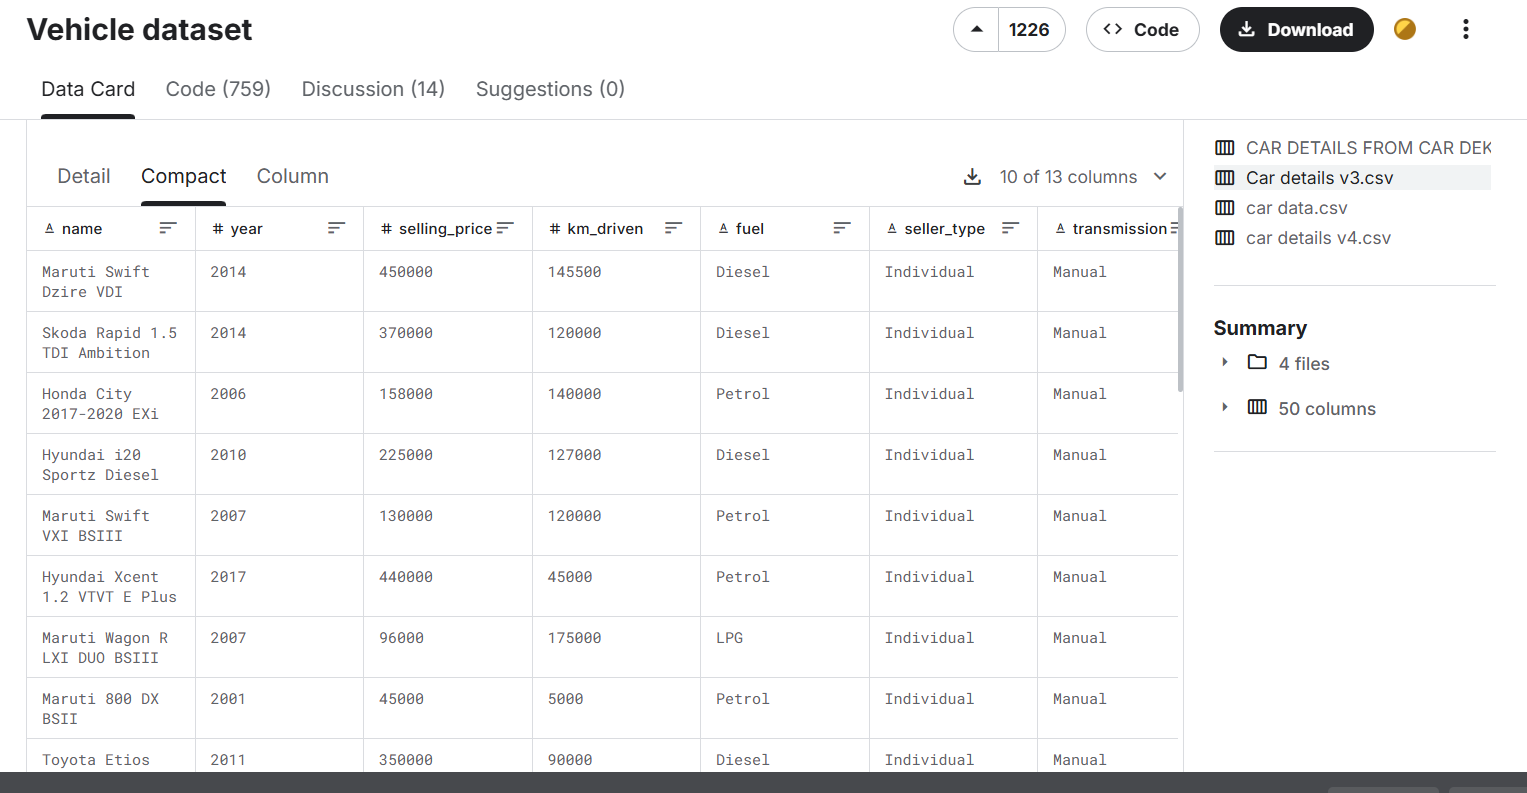

**Justificación:**<br>
Este dataset fue seleccionado porque cumple con los requerimientos señalados por el docente y contiene información relevante sobre el mercado de vehículos usados. El conjunto de datos incluye variables comerciales y técnicas como la marca del vehículo (*name*), año de fabricación (*year*), precio de venta (*selling_price*), kilometraje recorrido (*km_driven*), tipo de combustible (*fuel*), tipo de vendedor (*seller_type*), transmisión (*transmission*), número de propietarios anteriores (*owner*), rendimiento de combustible (*mileage*), capacidad del motor (*engine*), potencia máxima (*max_power*), torque (*torque*) y número de asientos (*seats*).
El dataset es adecuado para aplicar técnicas de análisis exploratorio de datos (EDA) utilizando Python y Pandas permitiendo detectar tendencias, correlaciones, distribuciones de variables y posibles valores atípicos. Asimismo, facilita la creación de indicadores y visualizaciones interactivas para un dashboard analítico.<br>
Además permite analizar factores para la creación de dashboard, estos factores son el precio de los vehículos usados, identificación de tendencias del mercado y aplicación de técnicas de análisis exploratorio de datos utilizando Python y Pandas.

## ETAPA 2 – Carga y procesamiento

_Importamos librerías:_

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

_Cargar los datos:_

In [2]:
df = pd.read_csv("car_data.csv")

In [3]:
print("Vista preliminar")
df.head()

Vista preliminar


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


In [4]:
df.tail()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
8123,Hyundai i20 Magna,2013,320000,110000,Petrol,Individual,Manual,First Owner,18.5 kmpl,1197 CC,82.85 bhp,113.7Nm@ 4000rpm,5.0
8124,Hyundai Verna CRDi SX,2007,135000,119000,Diesel,Individual,Manual,Fourth & Above Owner,16.8 kmpl,1493 CC,110 bhp,"24@ 1,900-2,750(kgm@ rpm)",5.0
8125,Maruti Swift Dzire ZDi,2009,382000,120000,Diesel,Individual,Manual,First Owner,19.3 kmpl,1248 CC,73.9 bhp,190Nm@ 2000rpm,5.0
8126,Tata Indigo CR4,2013,290000,25000,Diesel,Individual,Manual,First Owner,23.57 kmpl,1396 CC,70 bhp,140Nm@ 1800-3000rpm,5.0
8127,Tata Indigo CR4,2013,290000,25000,Diesel,Individual,Manual,First Owner,23.57 kmpl,1396 CC,70 bhp,140Nm@ 1800-3000rpm,5.0


_Revisar tipos de variables._

In [5]:
df.dtypes

name              object
year               int64
selling_price      int64
km_driven          int64
fuel              object
seller_type       object
transmission      object
owner             object
mileage           object
engine            object
max_power         object
torque            object
seats            float64
dtype: object

_Identificar registros duplicados_

In [6]:
duplicados = df.duplicated().sum()
print("Registros duplicados:", duplicados)

Registros duplicados: 1202


_Detectar valores faltantes._

In [7]:
df.isnull().sum()

name               0
year               0
selling_price      0
km_driven          0
fuel               0
seller_type        0
transmission       0
owner              0
mileage          221
engine           221
max_power        215
torque           222
seats            221
dtype: int64

_Realizar conversiones necesaria:_

In [8]:
# Visualización inicial de las columnas que requieren limpieza
df[["mileage","engine","max_power","torque"]].head()

,mileage,engine,max_power,torque
0,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm
1,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm
2,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)"
3,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm
4,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)"


In [9]:
# Usamos un bucle para aplicar la misma lógica a las tres columnas que requieren limpieza
columnas_a_limpiar = ['mileage', 'engine', 'max_power']

# 1. Se extrae únicamente la parte numérica mediante expresiones regulares.
# 2. Se convierte el resultado a tipo numérico.
# 3. Los valores faltantes generados durante la conversión se reemplazan por la mediana de cada columna.
for col in columnas_a_limpiar:
    df[col] = df[col].astype(str).str.extract(r'(\d+\.?\d*)')
    df[col] = pd.to_numeric(df[col], errors='coerce')
    df[col] = df[col].fillna(df[col].median())

# Limpieza de 'seats' (ya es numérica, solo rellenamos nulos)
df['seats'] = df['seats'].fillna(df['seats'].median())

# La columna de torque es extremadamente compleja (mezcla Nm, kgm, formatos distintos como @, at, etc).
# Entonces podemos ignorarla:
df.drop(columns=["torque"], inplace=True, errors="ignore")

print("\nValores nulos después de la limpieza:")
print(df.isnull().sum())


Valores nulos después de la limpieza:
name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
mileage          0
engine           0
max_power        0
seats            0
dtype: int64


## ETAPA 3 – Análisis exploratorio

_Dimensiones del dataset:_

In [10]:
df.shape

(8128, 12)

El conjunto de datos contiene 8128 registros y 13 variables

_Tipos de variables:_

In [11]:
df.dtypes

name              object
year               int64
selling_price      int64
km_driven          int64
fuel              object
seller_type       object
transmission      object
owner             object
mileage          float64
engine           float64
max_power        float64
seats            float64
dtype: object

_Estadísticas descriptivas:_

In [12]:
df.describe()

,year,selling_price,km_driven,mileage,engine,max_power,seats
count,8128.000000,8.128000e+03,8.128000e+03,8128.000000,8128.00000,8128.000000,8128.000000
mean,2013.804011,6.382718e+05,6.981951e+04,19.415554,1452.89813,91.264982,5.405389
std,4.044249,8.062534e+05,5.655055e+04,3.981922,498.19672,35.376388,0.948874
min,1983.000000,2.999900e+04,1.000000e+00,0.000000,624.00000,0.000000,2.000000
25%,2011.000000,2.549990e+05,3.500000e+04,16.800000,1197.00000,68.100000,5.000000
50%,2015.000000,4.500000e+05,6.000000e+04,19.300000,1248.00000,82.000000,5.000000
75%,2017.000000,6.750000e+05,9.800000e+04,22.277500,1582.00000,101.250000,5.000000
max,2020.000000,1.000000e+07,2.360457e+06,42.000000,3604.00000,400.000000,14.000000


_Distribuciones (Variables numericas):_

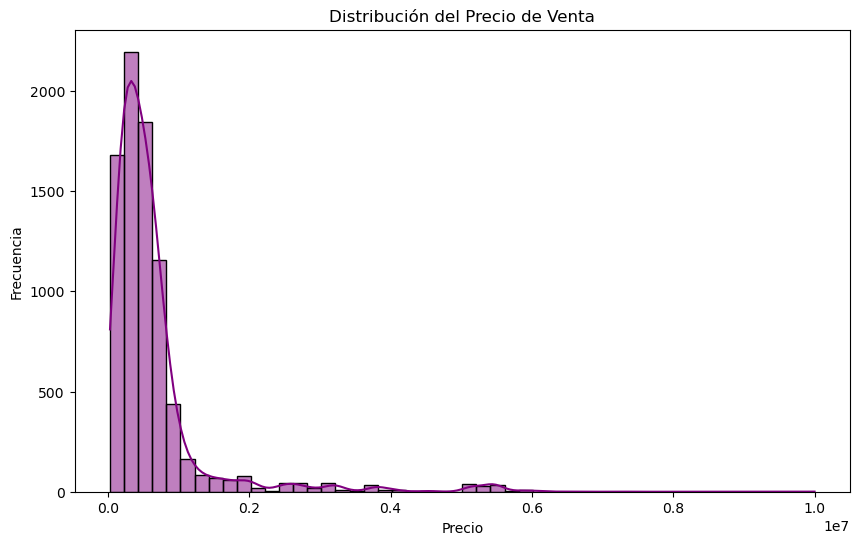

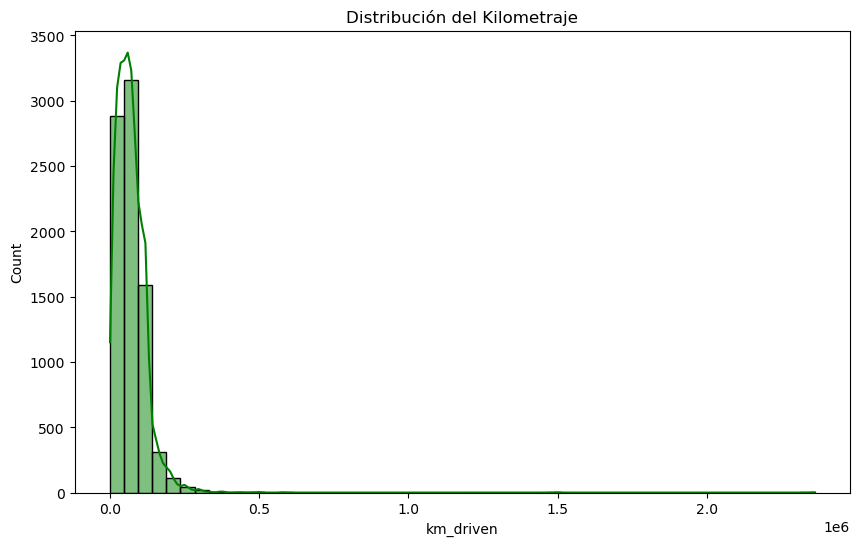

In [13]:
# Distribución de la variable objetivo: selling_price
plt.figure(figsize=(10, 6))
sns.histplot(df['selling_price'], bins=50, kde=True, color='purple')
plt.title('Distribución del Precio de Venta')
plt.xlabel('Precio')
plt.ylabel('Frecuencia')
plt.show()

# Distribución de KM recorridos
plt.figure(figsize=(10, 6))
sns.histplot(df['km_driven'], bins=50, kde=True, color='green')
plt.title('Distribución del Kilometraje')
plt.show()

_Variables categóricas:_

In [14]:
df["fuel"].value_counts()

fuel
Diesel    4402
Petrol    3631
CNG         57
LPG         38
Name: count, dtype: int64

In [15]:
df["transmission"].value_counts()

transmission
Manual       7078
Automatic    1050
Name: count, dtype: int64

_Valores extremos:_

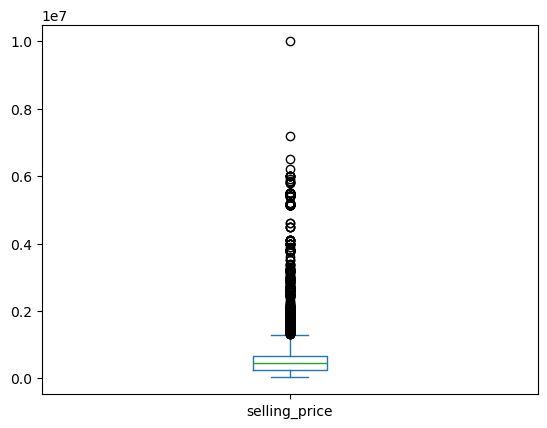

In [16]:
df["selling_price"].plot(kind="box")
plt.show()

_Principales hallazgos encontrados:_
- Impacto de los Valores Extremos: Tal como se observa en el gráfico de caja (boxplot) de selling_price, existen vehículos con precios significativamente superiores al promedio. Estos valores atípicos (outliers) corresponden a vehículos de gama alta o modelos poco comunes, los cuales deben ser considerados si se planea entrenar un modelo de predicción, ya que podrían sesgar los resultados.

- Correlación Negativa: Existe una relación inversa clara entre el kilometraje (km_driven) y el precio de venta; a mayor uso del vehículo, la caída en su valor comercial es acelerada durante los primeros años.

- Tendencia de Combustible: El mercado analizado muestra una preferencia marcada por motores Diesel y gasolina, siendo estos los que presentan mayor volumen de registros.

- Efecto de la Antigüedad: Al contrastar year con selling_price, se confirma que el año de fabricación es la variable con mayor peso en la determinación del valor del vehículo, más allá de otros factores técnicos como la potencia (max_power).

## ETAPA 4 – Consultas y transformaciones

_Filtrado de información:_

In [17]:
autos_modernos_potentes = df[
    (df["year"]>=2018) &
    (df["max_power"]>100)
]
autos_modernos_potentes.head(6)

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats
37,Hyundai Verna VTVT 1.6 SX Option,2019,1149000,5000,Petrol,Individual,Manual,First Owner,17.00,1591.0,121.30,5.0
41,Jeep Compass 1.4 Limited Plus BSIV,2019,2100000,5000,Petrol,Individual,Automatic,First Owner,16.00,1368.0,160.77,5.0
42,Honda City i VTEC VX,2018,925000,28900,Petrol,Dealer,Manual,First Owner,17.80,1497.0,117.30,5.0
53,Maruti Ciaz Zeta,2018,850000,64000,Petrol,Dealer,Manual,First Owner,20.65,1462.0,103.25,5.0
58,Toyota Corolla Altis 1.8 VL CVT,2018,1590000,25000,Petrol,Dealer,Automatic,First Owner,14.28,1798.0,138.03,5.0
110,Mahindra XUV500 W11 Option AWD,2019,1700000,32000,Diesel,Individual,Manual,First Owner,15.10,2179.0,155.00,7.0


_Ordenamiento:_

In [18]:
# Ordenar el dataset por precio de venta de mayor a menor:
df_ordenado = df.sort_values(by="selling_price", ascending=False)
df_ordenado.head(12)

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats
170,Volvo XC90 T8 Excellence BSIV,2017,10000000,30000,Petrol,Individual,Automatic,First Owner,42.00,1969.0,400.00,4.0
2938,BMW X7 xDrive 30d DPE,2020,7200000,5000,Diesel,Individual,Automatic,First Owner,13.38,2993.0,265.00,7.0
4952,Audi A6 35 TFSI Matrix,2019,6523000,23600,Petrol,Dealer,Automatic,Test Drive Car,15.26,1798.0,187.74,5.0
4950,Audi A6 35 TFSI Matrix,2019,6223000,7800,Petrol,Dealer,Automatic,Test Drive Car,15.26,1798.0,187.74,5.0
136,Mercedes-Benz S-Class S 350 CDI,2017,6000000,37000,Diesel,Dealer,Automatic,First Owner,13.50,2987.0,254.79,5.0
4101,BMW 6 Series GT 630d Luxury Line,2018,6000000,28156,Diesel,Dealer,Automatic,First Owner,17.09,2993.0,261.40,4.0
4766,BMW 6 Series GT 630d Luxury Line,2018,6000000,27000,Diesel,Dealer,Automatic,First Owner,17.09,2993.0,261.40,4.0
1071,BMW 6 Series GT 630d Luxury Line,2018,6000000,28156,Diesel,Dealer,Automatic,First Owner,17.09,2993.0,261.40,4.0
7713,Mercedes-Benz S-Class S 350 CDI,2017,6000000,37000,Diesel,Dealer,Automatic,First Owner,13.50,2987.0,254.79,5.0
5258,Mercedes-Benz S-Class S 350 CDI,2017,6000000,37000,Diesel,Dealer,Automatic,First Owner,13.50,2987.0,254.79,5.0


_Agrupaciones:_

In [19]:
# Agrupamos por seller__type lso 3 primeros de cada uno
agrupacion_vendedor = df.groupby("seller_type")
agrupacion_vendedor.head(3)

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74.00,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78.00,5.0
42,Honda City i VTEC VX,2018,925000,28900,Petrol,Dealer,Manual,First Owner,17.80,1497.0,117.30,5.0
43,Honda City V MT,2013,425000,86300,Petrol,Dealer,Manual,First Owner,16.80,1497.0,116.30,5.0
44,Maruti Swift Dzire VXi AT,2018,675000,23300,Petrol,Dealer,Automatic,First Owner,18.50,1197.0,83.14,5.0
375,Toyota Camry 2.5 Hybrid,2016,2000000,68089,Petrol,Trustmark Dealer,Automatic,First Owner,19.16,2494.0,157.70,5.0
376,Maruti Wagon R LXI,2013,225000,58343,Petrol,Trustmark Dealer,Manual,First Owner,21.79,998.0,67.05,5.0
378,Honda Jazz VX,2016,550000,56494,Petrol,Trustmark Dealer,Manual,First Owner,18.20,1199.0,88.70,5.0


_Conteos:_

In [20]:
conteo_vendedores = agrupacion_vendedor["name"].count()
conteo_vendedores

seller_type
Dealer              1126
Individual          6766
Trustmark Dealer     236
Name: name, dtype: int64

_Promedios:_

In [21]:
promedio_precio_vendedor = agrupacion_vendedor["selling_price"].mean()
promedio_precio_vendedor

seller_type
Dealer              1.443494e+06
Individual          4.985612e+05
Trustmark Dealer    8.018390e+05
Name: selling_price, dtype: float64

_Sumas:_

In [22]:
suma_ventas_fuel = df.groupby("fuel")["selling_price"].sum()
suma_ventas_fuel

fuel
CNG         17157997
Diesel    3483975761
LPG          7616000
Petrol    1679123495
Name: selling_price, dtype: int64

_Creación de nuevas columnas:_

In [23]:
df["antiguedad"] = 2026 - df["year"]
df["precio_por_antiguedad"] = df["selling_price"] / (df["antiguedad"] + 1)
df[['name', 'antiguedad', 'precio_por_antiguedad']].head()

,name,antiguedad,precio_por_antiguedad
0,Maruti Swift Dzire VDI,12,34615.384615
1,Skoda Rapid 1.5 TDI Ambition,12,28461.538462
2,Honda City 2017-2020 EXi,20,7523.809524
3,Hyundai i20 Sportz Diesel,16,13235.294118
4,Maruti Swift VXI BSIII,19,6500.000000


_Transformaciones lógicas:_

In [24]:
categoria_lista = []

for year in df["year"]:
    if year >= 2017:
        categoria_lista.append("Reciente")
    else:
        categoria_lista.append("Antiguo")

df["antiguedad_cat"] = categoria_lista

print(df[["year", "antiguedad_cat"]].head())

   year antiguedad_cat
0  2014        Antiguo
1  2014        Antiguo
2  2006        Antiguo
3  2010        Antiguo
4  2007        Antiguo


## ETAPA 5 – Visualización de datos

_Gráfico de barras:_

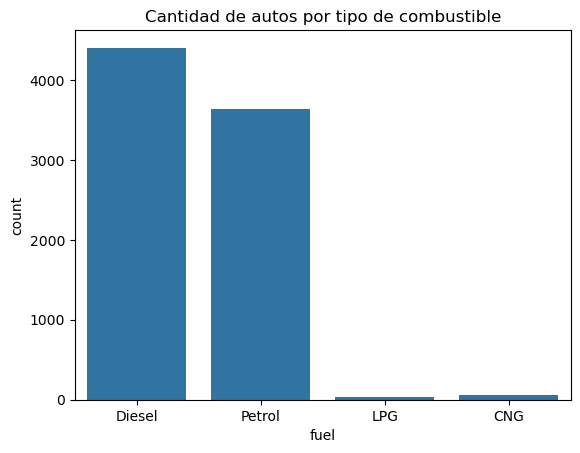

In [25]:
sns.countplot(x="fuel", data=df)
plt.title("Cantidad de autos por tipo de combustible")
plt.show()

**Interpretación:<br>** Este gráfico permite observar qué tipo de combustible predomina en el mercado, siendo Diesel y Gasolina las categorías con mayor presencia, lo cual ayuda a entender la oferta actual de los vehículos usados.

_Histograma:_

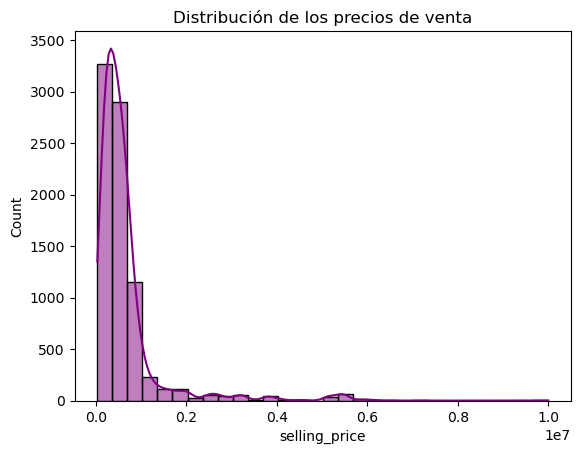

In [26]:
sns.histplot(df["selling_price"], bins=30, kde=True, color="purple")
plt.title("Distribución de los precios de venta")
plt.show()

**Interpretación:<br>** La mayoría de los vehículos se concentran en un rango de precio bajo, mostrando una distribución sesgada hacia la derecha, con pocos casos de vehículos de alta gama (valores atípicos).

_Gráfico de líneas:_

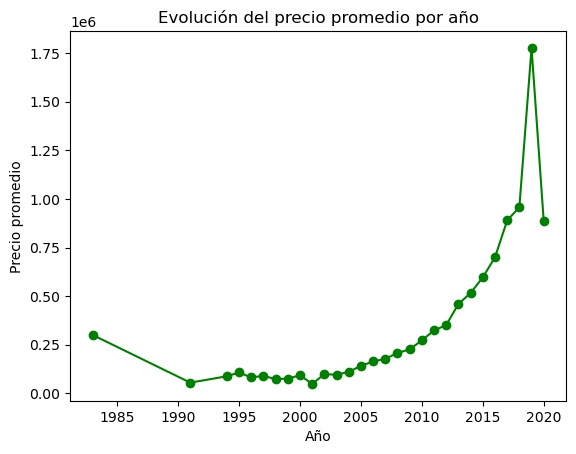

In [27]:
precio_por_anio = df.groupby("year")["selling_price"].mean()

precio_por_anio.plot(kind="line", marker="o", color="green")
plt.title("Evolución del precio promedio por año")
plt.xlabel("Año")
plt.ylabel("Precio promedio")
plt.show()

**Interpretación:<br>** Se observa una tendencia clara: a medida que el año del vehículo es más reciente, el precio promedio de venta tiende a aumentar, confirmando la relación directa entre la antigüedad y el valor del bien.

_Gráfico circular o equivalente:_

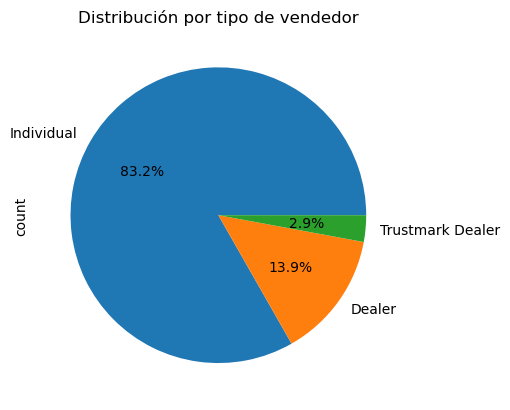

In [28]:
df["seller_type"].value_counts().plot(kind="pie", autopct='%1.1f%%')
plt.title("Distribución por tipo de vendedor")
plt.show()

**Interpretación:<br>** La mayor parte de las transacciones son realizadas por vendedores particulares (Individual), lo que indica que el mercado de usados está compuesto principalmente por ventas entre personas naturales.

_Gráfico de dispersión:_

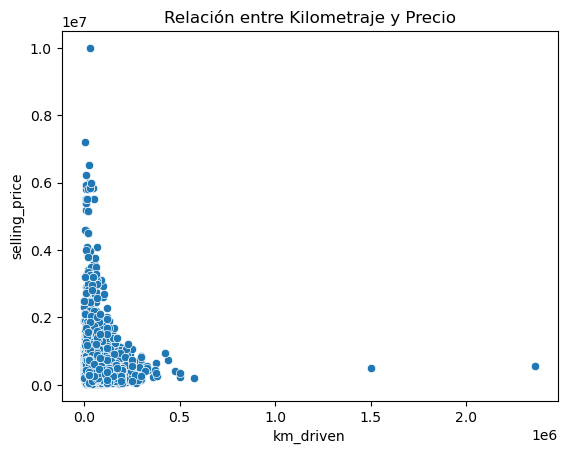

In [29]:
sns.scatterplot(x="km_driven", y="selling_price", data=df)
plt.title("Relación entre Kilometraje y Precio")
plt.show()

**Interpretación:<br>** Se observa una correlación negativa: los vehículos con un kilometraje muy elevado tienden a presentar precios de venta más bajos, lo que refleja el desgaste y la depreciación asociada al uso.

_Visualización comparativa:_

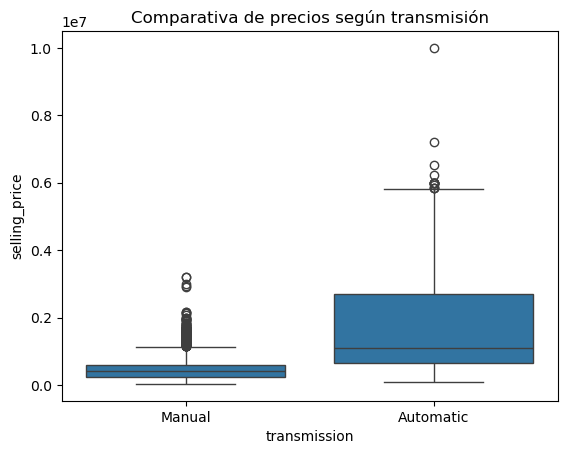

In [30]:
sns.boxplot(x='transmission', y='selling_price', data=df)
plt.title('Comparativa de precios según transmisión')
plt.show()

**Interpretación:<br>** Los vehículos con transmisión automática suelen alcanzar precios más altos en el mercado en comparación con los de transmisión manual, sugiriendo que la tecnología de transmisión es un factor diferenciador en el costo.